## **Implementing Word2Vec from Scratch**

Let's download the IMDB dataset in raw format.

In [1]:
import tensorflow as tf
from tensorflow import keras
import os, pathlib, shutil, random

zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


Make a TextVectorization layer that integer encodes all words in the IMDB data.

In [2]:
from keras import layers

# The underscore is ignored by Python and just makes the number easier to read :).
max_tokens = 20_000

# Make a TF dataset object using the text files in the training directory.
dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)

# Pull out the text alone (drop the labels)
text_dataset = dataset.map(lambda text,label: text,num_parallel_calls=8)

# Make a text vectorization layer that will encode integer sequences for the 20,000 most common terms.
tokenize_no_padding = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
)

tokenize_no_padding.adapt(text_dataset)

Found 75000 files belonging to 3 classes.


Define functions we can use against the Tensorflow Dataset object to parse out observations (context words + predicted word labels).

In [3]:
# We will look at 4 words on either side of a given word and we will try to predict them!
# 4 + word + 4 = 9 word window.
context_size = 4
window_size = 9

# We are going to iterate over the text in our sample to make training observations.
def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

# The 5th observation (0 indexed) will be our label.
def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1:]
    bag = tf.concat((left, right), axis=0)
    label = window[4]
    return bag, label

# Apply the Text Vectorizer to our data
dataset = text_dataset.map(tokenize_no_padding, num_parallel_calls=8)

# Apply the sample construction function (pull out 9 words at a time in sequence, for all possible sequences).
dataset = dataset.interleave(window_data, num_parallel_calls=8)

# Pull out our labels vs. context windows.
dataset = dataset.map(split_label, num_parallel_calls=8)

Define structure of our Neural Network

In [4]:
hidden_dim = 64

# We have 8 input tokens (surrounding the predicted word, which is our label)
inputs = keras.Input(shape=(2 * context_size,))

# We get the embeddings for each of those 8 words.
# Eventually the embeddings we learn here can be useful elsewhere!
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)

# We then Average the embeddings to end up with a vector output
x = layers.GlobalAveragePooling1D()(x)

# We then put those into big softmax (20,000 nodes, one per word in our vocab)
outputs = layers.Dense(max_tokens, activation="softmax")(x)

cbow_model = keras.Model(inputs, outputs)

cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

cbow_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 8, 64)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20000)          │     1,300,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,580,000 (9.84 MB)

 Trainable params: 2,580,000 (9.84 MB)

 Non-trainable params: 0 (0.00 B)

Finally, let's fit the model...

Fit the Neural Net to our data. We achieve about 15% accuracy, eventually. Note that we don't need a super high predictive performance for the embeddings to be useful. We also are not super worried about overfitting here because this is not a traditional prediction problem... there isn't 'noise' to fit to, really, because we are working with all the text in a very large corpus.

In [5]:
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=6)

Epoch 1/6
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 269s 16ms/step - loss: 6.5373 - sparse_categorical_accuracy: 0.0868
Epoch 2/6
   34/16503 ━━━━━━━━━━━━━━━━━━━━ 1:19 5ms/step - loss: 5.9003 - sparse_categorical_accuracy: 0.1276

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16503/16503 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 5.8298 - sparse_categorical_accuracy: 0.1284
Epoch 3/6
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 5.6685 - sparse_categorical_accuracy: 0.1356
Epoch 4/6
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 5.5939 - sparse_categorical_accuracy: 0.1378
Epoch 5/6
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 5.5503 - sparse_categorical_accuracy: 0.1389
Epoch 6/6
16503/16503 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step - loss: 5.5213 - sparse_categorical_accuracy: 0.1395


And now we can extract the embeddings for specific words and show that they really do capture semantic meaning!

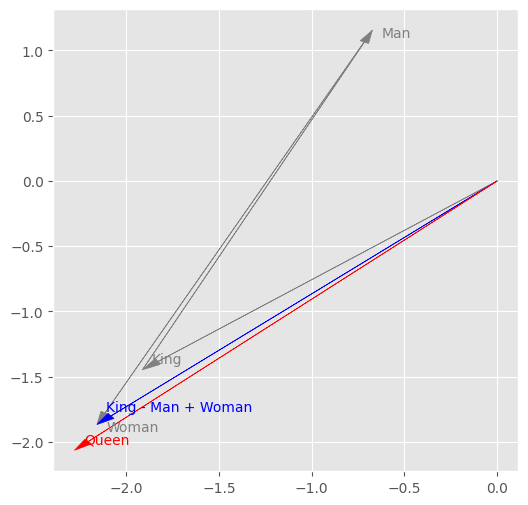

In [7]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get the embedding layer from the CBOW model
embedding_layer = cbow_model.get_layer('embedding')

# Get the vocabulary (word-to-index mapping)
vocab = tokenize_no_padding.get_vocabulary()

# Function to get the vector representation of a word
def get_word_vector(word):
  word_index = vocab.index(word)
  return embedding_layer(tf.constant([word_index])).numpy()[0]

# Get the vector representations for the desired words
king_vector = get_word_vector('king')
queen_vector = get_word_vector('queen')
man_vector = get_word_vector('man')
woman_vector = get_word_vector('woman')

# Calculate the "King - Man + Woman" vector
result_vector = king_vector - man_vector + woman_vector

# Initialize PCA and fit it to the embedding space
# We are fitting on the embedding layer weights to learn the principal components
pca = PCA(n_components=2)
pca.fit(embedding_layer.get_weights()[0]) # Get weights from the embedding layer

## Reduce vectors to 2D using PCA
result_vector_2d = pca.transform(np.array([result_vector]))[0]
queen_vector_2d = pca.transform(np.array([queen_vector]))[0]
king_vector_2d = pca.transform(np.array([king_vector]))[0]
man_vector_2d = pca.transform(np.array([man_vector]))[0]
woman_vector_2d = pca.transform(np.array([woman_vector]))[0]

# Apply ggplot style
plt.style.use('ggplot')

# Plot the vectors as lines with arrows
plt.figure(figsize=(6, 6))

# Plot King vector
plt.arrow(0, 0, king_vector_2d[0], king_vector_2d[1], head_width=0.05, head_length=0.1, fc='gray', ec='gray', length_includes_head=True)
plt.text(king_vector_2d[0] + 0.05, king_vector_2d[1] + 0.05, 'King', color='gray') # Adjusted label position

# Plot Man vector, starting from King's tip (subtraction)
plt.arrow(king_vector_2d[0], king_vector_2d[1], -man_vector_2d[0], -man_vector_2d[1], head_width=0.05, head_length=0.1, fc='gray', ec='gray', length_includes_head=True)
plt.text(king_vector_2d[0] - man_vector_2d[0] + 0.05, king_vector_2d[1] - man_vector_2d[1] -0.05, 'Man', color='gray') # Adjusted label position

# Plot Woman vector, starting from King - Man's tip (addition)
plt.arrow(king_vector_2d[0] - man_vector_2d[0], king_vector_2d[1] - man_vector_2d[1], woman_vector_2d[0], woman_vector_2d[1], head_width=0.05, head_length=0.1, fc='gray', ec='gray', length_includes_head=True)
plt.text(result_vector_2d[0] + 0.05, result_vector_2d[1] - 0.05, 'Woman', color='gray') # Adjusted label position

# Plot "King - Man + Woman" vector (resultant)
plt.arrow(0, 0, result_vector_2d[0], result_vector_2d[1], head_width=0.05, head_length=0.1, fc='blue', ec='blue', length_includes_head=True)
plt.text(result_vector_2d[0] + 0.05, result_vector_2d[1] + 0.1, 'King - Man + Woman', color='blue') # Adjusted label position

# Plot "Queen" vector
plt.arrow(0, 0, queen_vector_2d[0], queen_vector_2d[1], head_width=0.05, head_length=0.1, fc='red', ec='red', length_includes_head=True)
plt.text(queen_vector_2d[0] + 0.05, queen_vector_2d[1] + 0.05, 'Queen', color='red')  # Adjusted label position

plt.show()